# 03. Sky view factor

Stand on a cell and look up. How much of the sky can you actually see? An open park is
about 1, an alley is about 0.1 covered by walls.

That one number decides how much diffuse light lands on you, and how much of your own
heat escapes upward instead of bouncing back off a facade. Out comes `svf_bldg` and
`svf_veg`.

In [51]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pyproj import Transformer

CONFIG = json.load(open("config.json"))

W, H = CONFIG["grid"]["width"], CONFIG["grid"]["height"]
MINX, MAXY = CONFIG["grid"]["minx"], CONFIG["grid"]["maxy"]
CELL = CONFIG["cell_size"]

to_m = Transformer.from_crs(CONFIG["crs"]["wgs84"], CONFIG["crs"]["mga55"], always_xy=True)

In [52]:
dsm  = np.load("out/rasters/dsm_buildings.npy")
top  = np.load("out/rasters/dsm_canopy_top.npy")     # crown top from 02
base = np.load("out/rasters/dsm_canopy_base.npy")    # crown base from 02

print(f"grid       {W} x {H} cells at {CELL:.0f} m")
print(f"buildings  max {dsm.max():5.1f} m   cover {(dsm > 0).mean() * 100:4.1f}%")
print(f"crown top  max {top.max():5.1f} m   cover {(top > 0).mean() * 100:4.1f}%")

grid       2438 x 2485 cells at 2 m
buildings  max 298.0 m   cover 23.1%
crown top  max  33.4 m   cover  7.5%


In [53]:
# cut out the middle 1500 x 1500 the entire box takes too long for testing
CROP_M = 3000   # 2m = 1 cell therefore 3000m = 1500 cells
half = int(CROP_M / CELL / 2)
CROP = np.s_[H // 2 - half:H // 2 + half, W // 2 - half:W // 2 + half]

print(f"CROP  {2 * half} x {2 * half} cells  ({CROP_M} x {CROP_M} m over the CBD)")

CROP  1500 x 1500 cells  (3000 x 3000 m over the CBD)


## One cell, one direction

Same march as calculating shadows with one change. There we walked toward the sun and asked whether anything cleared the beam. Here we walk in 16 directions and ask how high the tallest thing reaches — that angle is the horizon angle, and everything above it is the sky.

In [54]:
def cell_of(lon, lat):
    x, y = to_m.transform(lon, lat)
    return int((MAXY - y) / CELL), int((x - MINX) / CELL)

# 2 DEMO points one Alley and one open lawn
ALLEY = cell_of(144.96434, -37.81531)    # Little Collins St, between Swanston and Elizabeth
PARK = cell_of(144.97400, -37.82100)     # open lawn in Alexandra Gardens

for name, (r, c) in (("alley", ALLEY), ("park", PARK)):
    near = dsm[r - 15:r + 16, c - 15:c + 16]
    print(f"{name:8s} r{r} c{c}   tallest building within 30 m {near.max():5.1f} m")

alley    r1396 c1303   tallest building within 30 m  58.0 m
park     r1703 c1735   tallest building within 30 m   0.0 m


In [55]:
REACH = 500.0        # the same 500 m buffer like the grid buffer width

def horizon_angle(surface, r, c, az):
    """Highest angle anything covers the sky at, looking out on bearing az. Degrees."""
    a = np.radians(az)
    best = 0.0
    for k in np.arange(0.5, REACH / CELL, 0.5):          # half-cell steps outward
        rr, cc = int(round(r - k * np.cos(a))), int(round(c + k * np.sin(a)))
        if not (0 <= rr < H and 0 <= cc < W):
            break
        best = max(best, np.degrees(np.arctan(surface[rr, cc] / (k * CELL))))
    return best

In [56]:
# Due north out of both cells, buildings only.
for name, (r, c) in (("alley", ALLEY), ("park", PARK)):
    print(f"{name:8s} north  horizon {horizon_angle(dsm, r, c, 0.0):5.1f} deg")

alley    north  horizon  79.4 deg
park     north  horizon   3.6 deg


In [57]:
AZIMUTHS = np.arange(0, 360, 22.5)      # 16 directions, one every 22.5 deg

alley_h = np.array([horizon_angle(dsm, *ALLEY, a) for a in AZIMUTHS])
park_h = np.array([horizon_angle(dsm, *PARK, a) for a in AZIMUTHS])

print(f"{'azimuth':>8s} {'alley':>9s} {'park':>7s}")
for a, l, p in zip(AZIMUTHS, alley_h, park_h):
    print(f"{a:8.1f} {l:9.1f} {p:7.1f}")

 azimuth     alley    park
     0.0      79.4     3.6
    22.5      84.7     3.2
    45.0      86.4     2.8
    67.5      84.7     1.0
    90.0      67.9     5.4
   112.5      72.0     0.6
   135.0      76.3     1.4
   157.5      66.8     0.0
   180.0      72.7     0.0
   202.5      81.2     0.0
   225.0      84.1     2.0
   247.5      81.2     2.9
   270.0      78.3     3.6
   292.5      78.3     1.9
   315.0      75.5     3.0
   337.5      25.9     0.0


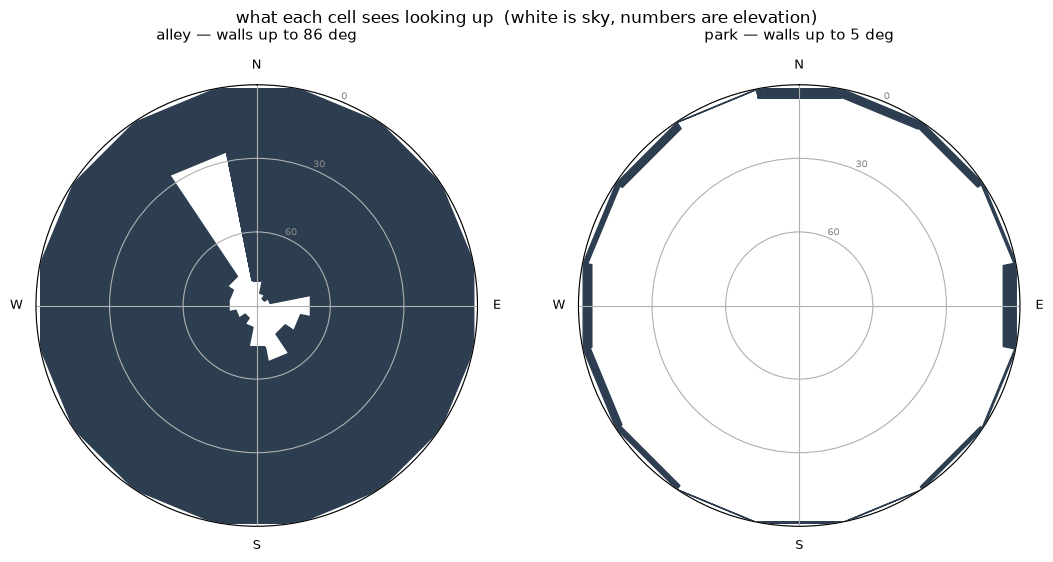

In [58]:
# Fisheye: centre is straight up, the rim is the horizon. Dark ring = blocked.
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), subplot_kw={"projection": "polar"})
th = np.radians(np.append(AZIMUTHS, 360.0) - 11.25)   # sector edges, so each bin is centred on its azimuth

for ax, h, title in ((axes[0], alley_h, "alley"), (axes[1], park_h, "park")):
    r = 90.0 - np.append(h, h[0])                    # how far down from the zenith sky starts
    ax.fill_between(th, r, 90.0, color="#2c3e50", step="post")
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
    ax.set_rlim(0, 90); ax.set_rticks([30, 60, 90])
    ax.set_yticklabels(["60", "30", "0"], fontsize=7, color="#888")
    ax.set_xticks(np.radians([0, 90, 180, 270]))
    ax.set_xticklabels(["N", "E", "S", "W"], fontsize=9)
    ax.set_title(f"{title} — walls up to {h.max():.0f} deg", fontsize=11, pad=14)

fig.suptitle("what each cell sees looking up  (white is sky, numbers are elevation)", fontsize=12)
fig.tight_layout()

## Turning 16 angles into one number

Sky straight overhead is worth more than sky near the horizon. Flat ground faces the zenith
head on and the horizon edge on, so light from low down barely lands. Add that up over one
direction and it comes out $\cos^2\gamma$.

$$\text{SVF} \;=\; \frac{1}{N}\sum_{i=1}^{N}\cos^{2}\gamma_i$$

| symbol | what it is |
|---|---|
| $N$ | 16, the directions we marched |
| $\gamma_i$ | the horizon angle in direction $i$, in degrees |
| SVF | 1 = nothing in the way, 0 = walled in on all sides |

A wall at $\gamma = 0$ blocks nothing, $\cos^2 0 = 1$. A wall straight up at $\gamma = 90$
blocks everything, $\cos^2 90 = 0$.

In [59]:
def svf_of(h):
    return np.mean(np.cos(np.radians(h)) ** 2)      # h is the 16 horizon angles

print(f"alley  SVF {svf_of(alley_h):.3f}")
print(f"park   SVF {svf_of(park_h):.3f}")

alley  SVF 0.100
park   SVF 0.998


## The whole 1500x1500 grid at once

Same march, except now every cell marches at the same time. `shift(a, dr, dc)` slides the
whole raster so each cell reads the height sitting `dr, dc` away from it, and one
`np.maximum` handles all 2 million cells in a single line. That is 01's trick.

Two changes for speed. Keep the tangent instead of the angle, so no `arctan` in the loop:

$$\tan\gamma = \max_{d}\frac{h(d)}{d} \qquad\qquad \cos^{2}\gamma = \frac{1}{1+\tan^{2}\gamma}$$

And march a **padded** window. A building 500 m outside the crop still blocks sky inside it,
so cut a wider slice, march that, then trim the padding off.

In [60]:
def shift(a, dr, dc):
    """out[r, c] = a[r + dr, c + dc], zero-padded. What each cell sees dr, dc away."""
    out = np.zeros_like(a)
    Hh, Ww = a.shape
    out[max(-dr, 0):Hh - max(dr, 0), max(-dc, 0):Ww - max(dc, 0)] = \
        a[max(dr, 0):Hh - max(-dr, 0), max(dc, 0):Ww - max(-dc, 0)]
    return out

def ray_offsets(az):
    """Integer (dr, dc, distance_m) steps out on bearing az, nearest first, no repeats."""
    a = np.radians(az)
    seen, offs = set(), []
    for k in np.arange(0.25, REACH / CELL, 0.25):        # quarter-cell steps, no gaps in the line
        dr, dc = int(round(-k * np.cos(a))), int(round(k * np.sin(a)))
        if (dr, dc) in seen or (dr, dc) == (0, 0):
            continue
        seen.add((dr, dc))
        offs.append((dr, dc, k * CELL))                  # first time seen = shortest true distance
    return offs

print(f"az 0 marches {len(ray_offsets(0.0))} cells out to {REACH:.0f} m")

az 0 marches 250 cells out to 500 m


In [61]:
def horizon_tan(surface, az):
    """tan of the horizon angle for every cell at once: max(h / d) along the march."""
    t = np.zeros(surface.shape, np.float32)
    for dr, dc, dist in ray_offsets(az):
        np.maximum(t, (shift(surface, dr, dc) - surface) / dist, out=t)
    return t

def svf(surface):
    s = np.zeros(surface.shape, np.float32)
    for az in AZIMUTHS:
        s += 1.0 / (1.0 + horizon_tan(surface, az) ** 2)     # cos^2 without the arctan
    return s / len(AZIMUTHS)

In [62]:
PAD = int(REACH / CELL)     # 250 cells = the 500 m a building can still reach across

rs, cs = CROP
PADDED = np.s_[rs.start - PAD:rs.stop + PAD, cs.start - PAD:cs.stop + PAD]
TRIM   = np.s_[PAD:-PAD, PAD:-PAD]                          # cuts the padding back off

svf_bldg = svf(dsm[PADDED])[TRIM]                           # buildings only, crowns ignored
print(f"svf_bldg   mean {svf_bldg.mean():.3f}   min {svf_bldg.min():.3f}   max {svf_bldg.max():.3f}")

svf_bldg   mean 0.736   min 0.000   max 1.000


In [63]:
# Leaves are not brick. A crown blocks most of the sky behind it but not all of it.
TAU_LEAF = 0.03        # fraction of light a canopy lets through

svf_all = svf(np.maximum(dsm, top)[PADDED])[TRIM]           # crowns treated as solid
svf_veg = svf_all + TAU_LEAF * (svf_bldg - svf_all)         # 3% of the sky the leaves took, given back

print(f"crowns solid  mean {svf_all.mean():.3f}")
print(f"with tau      mean {svf_veg.mean():.3f}")
print(f"canopy costs  {(svf_bldg - svf_veg).mean():.3f} of sky on average over the crop")

CONFIG["canopy"]["tau_leaf"] = TAU_LEAF
json.dump(CONFIG, open("config.json", "w"), indent=4)

crowns solid  mean 0.667
with tau      mean 0.669
canopy costs  0.067 of sky on average over the crop


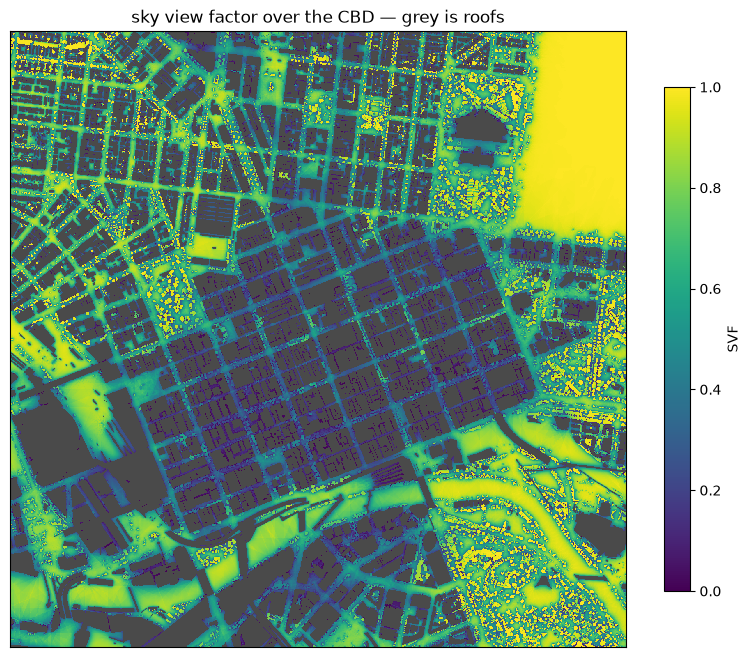

In [64]:
from matplotlib.colors import ListedColormap

# Roofs are greyed out. A cell on a roof measures its horizon against its own building 2 m
# away, so its SVF is meaningless — nobody stands there anyway.
bldg = dsm[CROP] > 0

fig, ax = plt.subplots(figsize=(8, 7.5))
ax.imshow(bldg, cmap=ListedColormap(["#ffffff", "#4a4a4a"]), interpolation="nearest")
im = ax.imshow(np.ma.masked_where(bldg, svf_veg), cmap="viridis", vmin=0, vmax=1,
               interpolation="nearest")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("sky view factor over the CBD — grey is roofs")
fig.colorbar(im, ax=ax, shrink=0.7, label="SVF")
fig.tight_layout()


## Generating an SVF raster for the whole grid

In [65]:
# The whole 2438 x 2485 grid. No padding needed — 00 already built a 500 m buffer into it.
# Two passes, so expect roughly double what the crop took.
svf_bldg_full = svf(dsm)
svf_all_full  = svf(np.maximum(dsm, top))
svf_veg_full  = svf_all_full + TAU_LEAF * (svf_bldg_full - svf_all_full)

np.save("out/rasters/svf_bldg.npy", svf_bldg_full)
np.save("out/rasters/svf_veg.npy", svf_veg_full)
print("saved out/rasters/svf_bldg.npy and svf_veg.npy")


saved out/rasters/svf_bldg.npy and svf_veg.npy
